# ECG workshop

## Setup environment

In [30]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.io import loadmat

plt.ion()  # Turn on interactive mode

'''
An alternative to matplotlib is plotly, which provides slightly 'fancier' interactive plots - but is also more complicated to use. It requres the following imports and setup:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected" 
'''

'\nAn alternative to matplotlib is plotly, which provides slightly \'fancier\' interactive plots - but is also more complicated to use. It requres the following imports and setup:\nimport plotly.graph_objects as go\nimport plotly.io as pio\npio.renderers.default = "notebook_connected" \n'

## Import data
### 1.	Load ekgu and plot the signal in black color with the time axis (t) given in seconds (the sampling frequency Fs is 500 Hz)
##### 1.A) What is the duration of the recording in seconds?

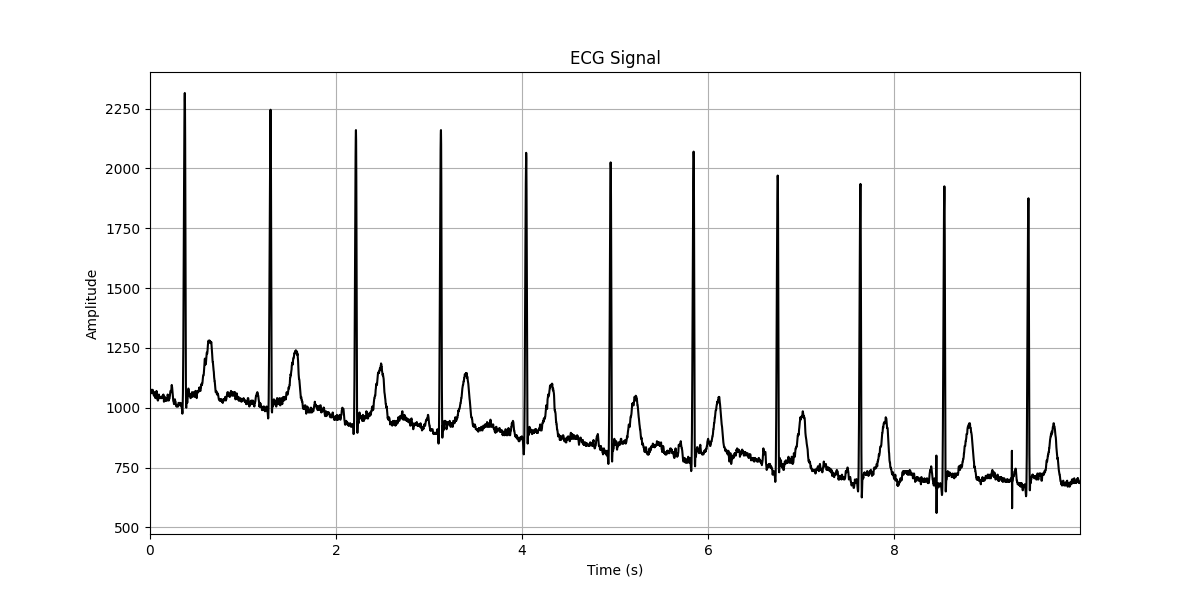

In [ ]:
path = r'C:\Users\MC99DK\OneDrive - Aalborg Universitet\Documents\DSP\moodle1'
ekgu = loadmat(path+'/ekgu.mat')
ekgu = ekgu['ekgu'].flatten()  # Assuming 'ekgu' is the key for the ECG data in the .mat file

fs = 500  # Sampling frequency in Hz
t = np.arange(0, len(ekgu)) / fs  # Time array in seconds

# Plot the ECG data
plt.figure(figsize=(15, 6))
plt.plot(t, ekgu, color='black')
plt.title('ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, t[-1])
plt.show()


#### 1a) What is the duration of the recording in seconds?

In [32]:
print("Duration of the recording: {:.2f} seconds".format(t[-1])) # The index of the last element of a vector is -1 in Python

Duration of the recording: 10.00 seconds


### 2.	Calculate the filter coefficients Bn and An for 4 different Butterworth lowpass filters:
#### A) Order = 2, cutoff frequency = 20 Hz 

In [33]:
# Define your parameters
N = 2          # Filter order
fc = 20        # Cutoff frequency in Hz

# Calculate coefficients (b = numerator, a = denominator)
b_2_20, a_2_20 = signal.butter(N, fc, btype='low', fs=fs)
print("Coefficients for 2nd order Butterworth filter with 20 Hz cutoff:")
print("b:", b_2_20)
print("a:", a_2_20)

Coefficients for 2nd order Butterworth filter with 20 Hz cutoff:
b: [0.0133592 0.0267184 0.0133592]
a: [ 1.         -1.64745998  0.70089678]


#### B) Order = 4, cutoff frequency = 20 Hz 

In [34]:
# Define your parameters
N = 4          # Filter order
fc = 20        # Cutoff frequency in Hz

# Calculate coefficients (b = numerator, a = denominator)
b_4_20, a_4_20 = signal.butter(N, fc, btype='low', fs=fs)
print("Coefficients for 4th order Butterworth filter with 20 Hz cutoff:")
print("b:", b_4_20)
print("a:", a_4_20)

Coefficients for 4th order Butterworth filter with 20 Hz cutoff:
b: [0.00018322 0.00073286 0.0010993  0.00073286 0.00018322]
a: [ 1.         -3.34406784  4.23886395 -2.40934286  0.5174782 ]


#### C) Order = 2, cutoff frequency = 40 Hz

In [35]:
# Define your parameters
N = 2          # Filter order
fc = 40        # Cutoff frequency in Hz

# Calculate coefficients (b = numerator, a = denominator)
b_2_40, a_2_40 = signal.butter(N, fc, btype='low', fs=fs)
print("Coefficients for 2nd order Butterworth filter with 40 Hz cutoff:")
print("b:", b_2_40)
print("a:", a_2_40)

Coefficients for 2nd order Butterworth filter with 40 Hz cutoff:
b: [0.0461318 0.0922636 0.0461318]
a: [ 1.         -1.30728503  0.49181224]


#### D) Order = 16, cutoff frequency = 40 Hz 

In [36]:
# Define your parameters
N = 16          # Filter order
fc = 40        # Cutoff frequency in Hz

# Calculate coefficients (b = numerator, a = denominator)
b_16_40, a_16_40 = signal.butter(N, fc, btype='low', fs=fs)
print("Coefficients for 16th order Butterworth filter with 40 Hz cutoff:")
print("b:", b_16_40)
print("a:", a_16_40)

Coefficients for 16th order Butterworth filter with 40 Hz cutoff:
b: [2.64816720e-11 4.23706751e-10 3.17780063e-09 1.48297363e-08
 4.81966430e-08 1.15671943e-07 2.12065229e-07 3.02950327e-07
 3.40819118e-07 3.02950327e-07 2.12065229e-07 1.15671943e-07
 4.81966430e-08 1.48297363e-08 3.17780063e-09 4.23706751e-10
 2.64816720e-11]
a: [ 1.00000000e+00 -1.08730955e+01  5.60234079e+01 -1.81419629e+02
  4.12966328e+02 -7.00230225e+02  9.14383221e+02 -9.37557494e+02
  7.62524003e+02 -4.93369485e+02  2.53022338e+02 -1.01738695e+02
  3.14339371e+01 -7.21239935e+00  1.15870350e+00 -1.16425451e-01
  5.51076712e-03]


#### 2a) What is the association between filter order and number of coefficients? 
The number of coefficients is N+1, where filter order = N.

## 3. Use forward filtering to filter ekgu with each of the 4 filters and use different colors to plot the 4 lowpass filtered ecg signals on top of the unfiltered ecg

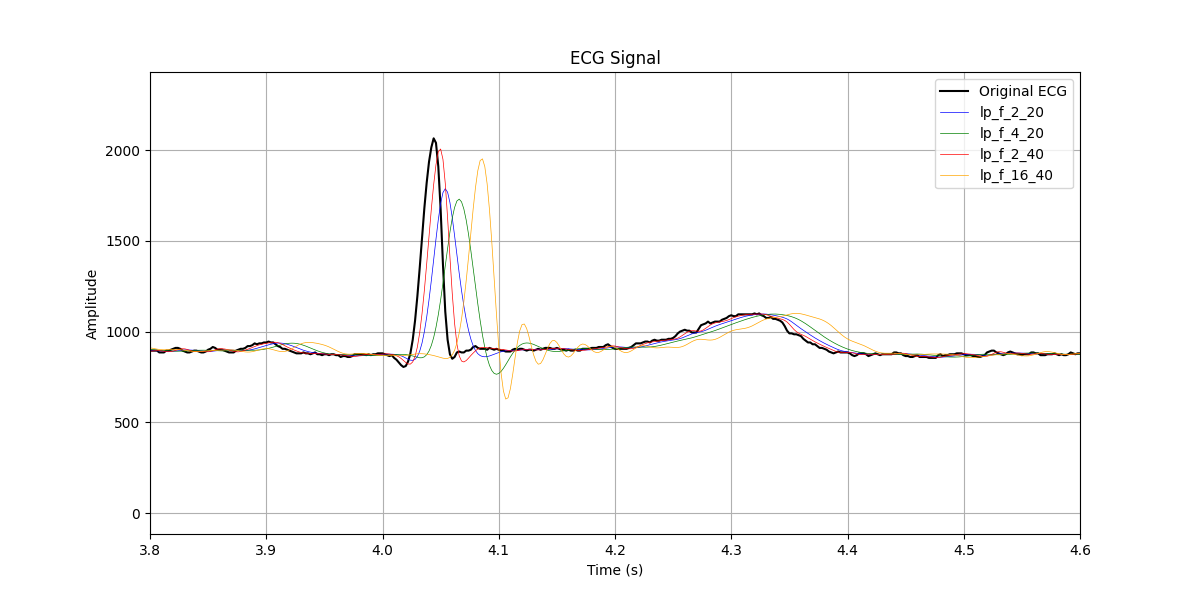

In [ ]:
# Applying the filter forward-only
lp_f_2_20 = signal.lfilter(b_2_20, a_2_20, ekgu) # N=2, fc=20
lp_f_4_20 = signal.lfilter(b_4_20, a_4_20, ekgu) # N=4, fc=20
lp_f_2_40 = signal.lfilter(b_2_40, a_2_40, ekgu) # N=2, fc=40
lp_f_16_40 = signal.lfilter(b_16_40, a_16_40, ekgu) # N=16, fc=40

# Plot the un-fitered and filtered ECG data
plt.figure(figsize=(15, 6))
plt.plot(t, ekgu, color='black')
plt.plot(t, lp_f_2_20, color='blue', linewidth=0.5)
plt.plot(t, lp_f_4_20, color='green', linewidth=0.5)
plt.plot(t, lp_f_2_40, color='red', linewidth=0.5)
plt.plot(t, lp_f_16_40, color='orange', linewidth=0.5)
plt.legend(['Original ECG', 'lp_f_2_20', 'lp_f_4_20', 'lp_f_2_40', 'lp_f_16_40'])  
plt.title('ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, t[-1]) # Set axis limits to the full duration of the signal
plt.xlim(3.8, 4.6) # This is only for printing, to zoom in on one heartbeat
plt.show()

#### 3a) How does filter order affect delay between the unfiltered ekgu and the filtered signals?
The higher the filter order is, the larger the delay is between the unfiltered and filtered signals.
#### 3b) An IIR filter does not have a linear phase. How does that affect delays of the different parts of the ECG? 
The QRS waveform has higher frequency content than the T-wave, which causes different delays for the QRS-complex and T-wave, respectively.
#### 3c) How does a higher order filter affect the depth of the Q-wave? (Infarct criteria)
All our 4 filters are reducing the dept of the Q-wave. The higher the order (and/or the lower the fc), the stronger this reduction is.
#### 3d) How does a higher order filter affect the shape of the ST-segment? (Infarct criteria)
Higher order filters (especially our 16th order filter) creates "ripples" in the ST-segment.
#### 3e) How does filter order and cutoff frequency affect QRS amplitude? (Infarct criteria)
QRS amplitude is reduced by filtering: The higher the filter order is, and the lower the cut-off frequency is, the more the amplitude is reduced.

### 4. Create a new figure. Use forward-backward filtering to filter ekgu with each of the 4 filters and use different colors to plot the 4 lowpass filtered ecg signals on top of the unfiltered ecgu.

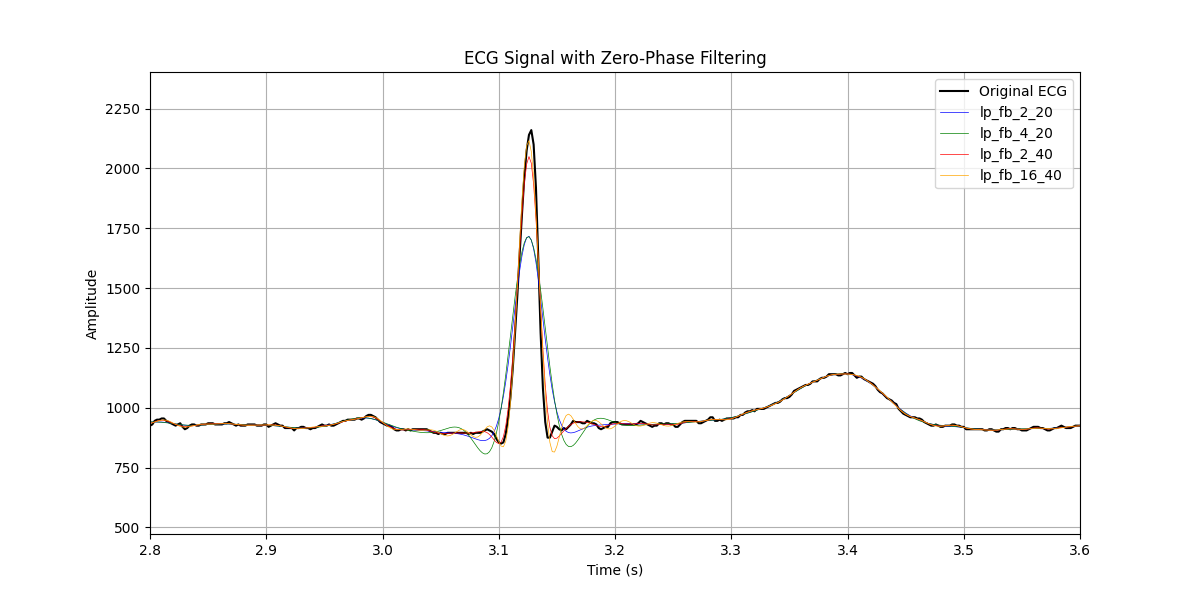

In [ ]:
# Applying the filter using forward-backward (zero-phase filtering)
lp_fb_2_20 = signal.filtfilt(b_2_20, a_2_20, ekgu, axis=0)   # N=2, fc=20
lp_fb_4_20 = signal.filtfilt(b_4_20, a_4_20, ekgu, axis=0)   # N=4, fc=20
lp_fb_2_40 = signal.filtfilt(b_2_40, a_2_40, ekgu, axis=0)   # N=2, fc=40
lp_fb_16_40 = signal.filtfilt(b_16_40, a_16_40, ekgu, axis=0) # N=16, fc=40

# Plot the un-fitered and filtered ECG data
plt.figure(figsize=(15, 6))
plt.plot(t, ekgu, color='black')
plt.plot(t, lp_fb_2_20, color='blue', linewidth=0.5)
plt.plot(t, lp_fb_4_20, color='green', linewidth=0.5)
plt.plot(t, lp_fb_2_40, color='red', linewidth=0.5)
plt.plot(t, lp_fb_16_40, color='orange', linewidth=0.5)
plt.legend(['Original ECG', 'lp_fb_2_20', 'lp_fb_4_20', 'lp_fb_2_40', 'lp_fb_16_40'])  
plt.title('ECG Signal with Zero-Phase Filtering')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, t[-1]) # Set axis limits to the full duration of the signal
plt.xlim(2.8, 3.6) # This is only for printing, to zoom in on one heartbeat
plt.show()

#### 4a) What is the delay between ekgu and the filtered signals after forward-backward filtering? What implications does that have for alignment with other signals such as for example echo?
There is no delay, which makes it simpler to align different types of signals.
#### 4b) What is the effect of forward-backward filtering on Q-wave depth compared to forward filtering alone? (Infarct criteria)
The dept of the Q-wave is increased. 
#### 4c) Assume the end of the T-wave is identical for all 4 signals (it looks that way). How many milliseconds difference is there between the QT intervals of signals: lp_fb_4_20 and lp_fb_16_40? (Drug safety criteria)
Around 28 ms
#### 4d) Which of the 4 filters appears to be the most suitable for filtering the ECG signal?
lp_fb_2_40 alters the ECG signal the least out of these four options and is thus the most suitable out of these options.
#### 4e) The last 2 beats have pacemaker-spikes. Would you notice on the ECG that the patient has a pacemaker if you use filtering?
No.

### 5. Calculate the filter coefficients B and A for a 2. order Butterworth highpass filter with a cutoff frequency of 0.05 Hz. Create a new figure. Use forward-backward filtering to filter the lp_fb_2_40 signal.  Use different colors to plot the highpass filtered ecg signal on top of the unfiltered ekgu.

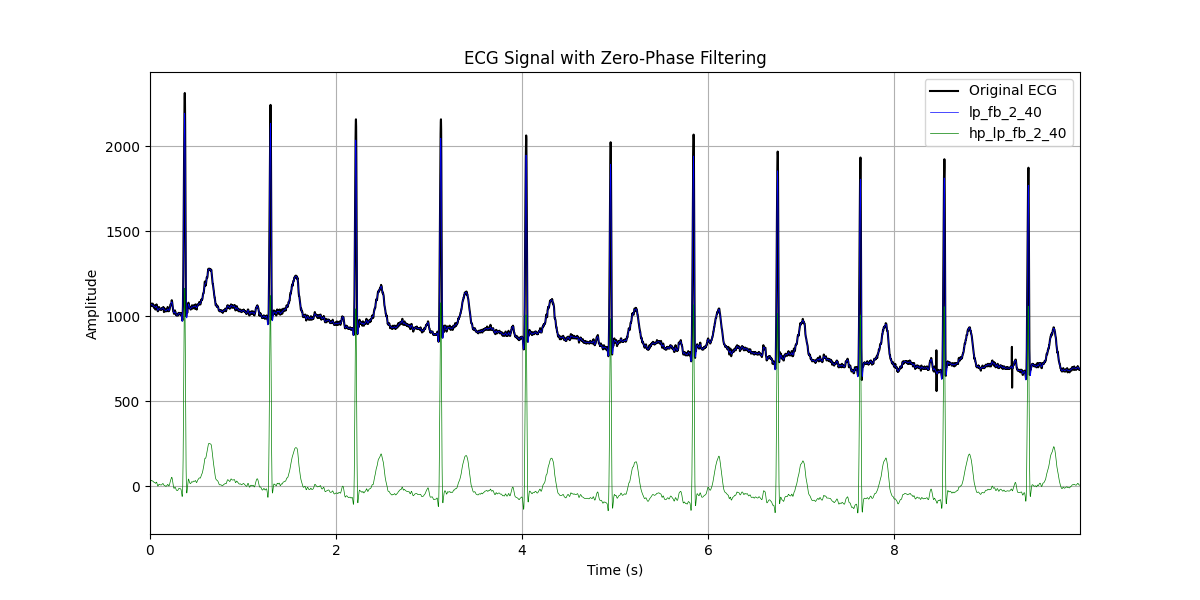

In [ ]:
# Define your parameters
N = 2          # Filter order
fc = 0.05      # Cutoff frequency in Hz

# Calculate coefficients (b = numerator, a = denominator)
b_2_005, a_2_005 = signal.butter(N, fc, btype='high', fs=fs)

# Applying the filter using forward-backward (zero-phase filtering)
hp_lp_fb_2_40 = signal.filtfilt(b_2_005, a_2_005, lp_fb_2_40, axis=0)   # N=2, fc=0.05

# Plot the un-fitered and filtered ECG data
plt.figure(figsize=(15, 6))
plt.plot(t, ekgu, color='black')
plt.plot(t, lp_fb_2_40, color='blue', linewidth=0.5)
plt.plot(t, hp_lp_fb_2_40, color='green', linewidth=0.5)
plt.legend(['Original ECG', 'lp_fb_2_40', 'hp_lp_fb_2_40'])  
plt.title('ECG Signal with Zero-Phase Filtering')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, t[-1])
plt.show()

#### 5a) What effect did highpass filtering have on the signal?
It removed the offset and the drift.

## Frequency spectra
### 6. Calculate a frequency spectrum for ekgu and for hp_lp_fb_2_40. Use different colors to plot the 2 frequency spectra on top of each other.

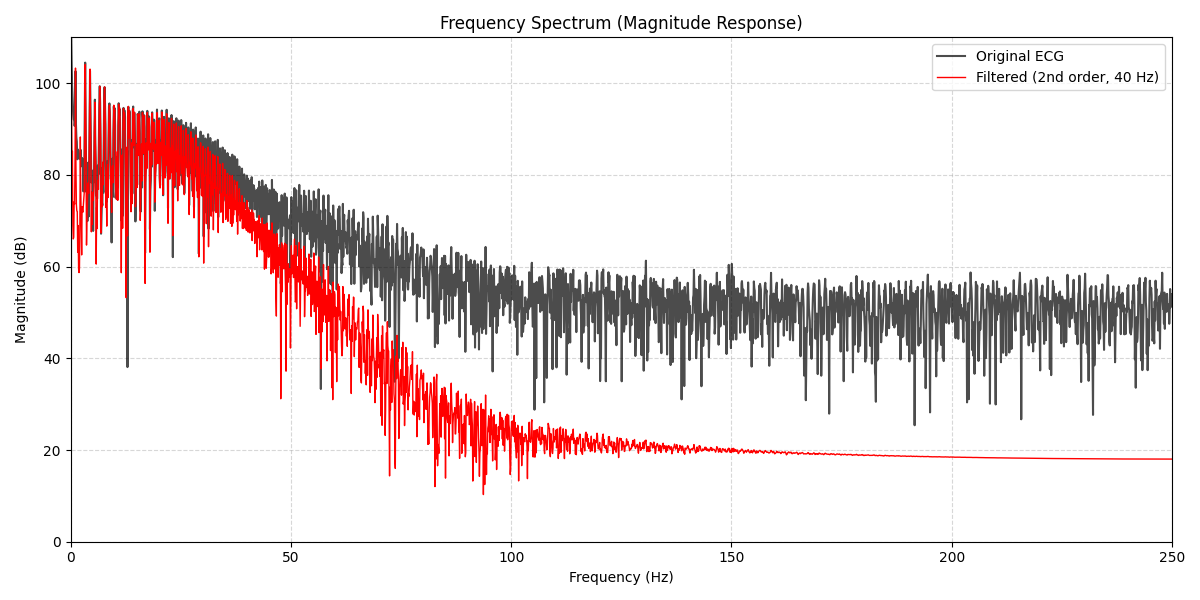

In [ ]:
def get_spectrum(sig, fs):
    # 1. Subtract mean (remove DC offset)
    sig_detrend = sig.flatten() - np.mean(sig)
    N = len(sig_detrend)
    
    # 2. Calculate FFT and take the absolute magnitude
    fft_vals = np.fft.fft(sig_detrend)
    mag = np.abs(fft_vals)
    
    # 3. Convert to dB (20*log10)
    # We add a tiny epsilon (1e-10) to avoid log(0) errors
    mag_db = 20 * np.log10(mag + 1e-10)
    
    # 4. Generate frequency axis
    freqs = np.fft.fftfreq(N, 1/fs)
    
    # 5. Take only the positive half
    half_n = N // 2
    return freqs[:half_n], mag_db[:half_n]

# Apply to your signals
f_u, fs_ekgu = get_spectrum(ekgu, fs=fs)
f_filt, fs_hp_lp_fb_2_40 = get_spectrum(hp_lp_fb_2_40, fs=fs)

# Create the figure
plt.figure(figsize=(15, 6))

# Plot both spectra
plt.plot(f_u, fs_ekgu, color='black', label='Original ECG', alpha=0.7)
plt.plot(f_filt, fs_hp_lp_fb_2_40, color='red', label='Filtered (2nd order, 40 Hz)', linewidth=1)

# Formatting
plt.title('Frequency Spectrum (Magnitude Response)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

# Zoom in on the relevant range (0 to Nyquist, or focus on 0-100Hz)
plt.xlim(0, 250)
plt.ylim(0,110) 
plt.tight_layout()

plt.show()

## Measuring heart rate
### 7.	Find all R-peak locations in the signal hp_lp_fb_2_40. Plot a marker (’o’) on each R-peak.

C:\Users\MC99DK\AppData\Local\Temp\ipykernel_26332\8948291.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 6))


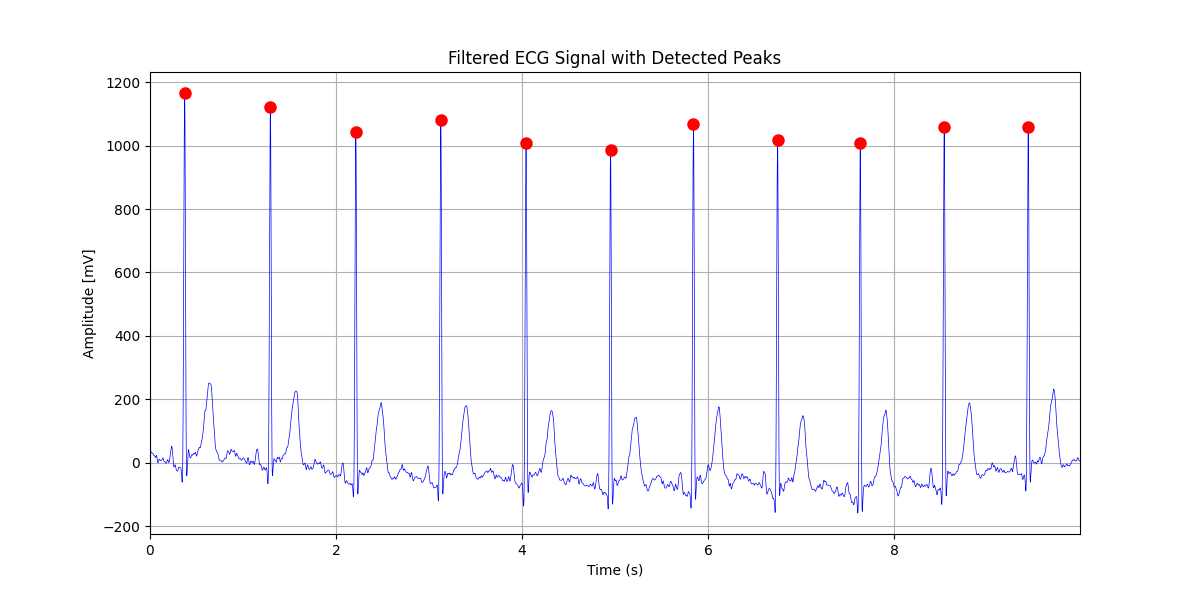

In [ ]:
# 1. Detect the peaks (returns indices)
# Distance: ~300 samples (assuming fs=500Hz, a heart rate >200bpm is unlikely)
# Height: Adjust based on your signal's filtered amplitude and unit
locs, properties = signal.find_peaks(hp_lp_fb_2_40.flatten(), distance=300, height=500)

# 2. Get the peak amplitudes
pks = hp_lp_fb_2_40.flatten()[locs]

# Plot the result
plt.figure(figsize=(15, 6))
plt.plot(t, hp_lp_fb_2_40, color='blue', linewidth=0.5)
plt.plot(t[locs], pks, 'ro', markersize=8, label='Detected Peaks')
plt.title('Filtered ECG Signal with Detected Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude [mV]')
plt.grid(True)
plt.xlim(0, t[-1])
plt.show()

### 8.	Calculate the heart rate from the average distance between QRS complexes
#### 8b) What is the average heart rate in beats per minute?

In [42]:
print("Average Heart Rate: {:.2f} bpm".format(len(locs) / (t[-1] / 60)))

Average Heart Rate: 66.01 bpm
